# 03 - Model Training & Validation (Enhanced)

In [22]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from pathlib import Path

# Import enhanced modules
from src.features import build_team_features, build_matchup_df
from src.model import (
    LogisticBaseline,
    XGBBaseline,
    MarchMadnessTrainer,
    EnsemblePredictor,
    evaluate,
    compute_calibration,
    compute_expected_calibration_error,
    manual_grid_search
)

PROC_DIR = Path('../data/processed')
OUT_DIR = Path('../outputs')
MODELS_DIR = Path('../models')

## 1. Rebuild Features with Enhanced Pipeline

In [23]:
# Rebuild team features with new pipeline
m_feats = build_team_features(gender='M', save=True)
w_feats = build_team_features(gender='W', save=True)

# dropping sag cuz of NAs
# m_feats.isna().sum()
#m_feats.drop('rank_SAG', axis = 1, inplace = True)

[M] Computing offensive Four Factors...
[M] Computing defensive Four Factors...
[M] Computing tempo and efficiency...
[M] Loading seed data...
[M] Merging all features...
[M] Saved to /Users/adamgold/Desktop/MM_26/data/processed/M_team_features.csv
[M] Shape: (8346, 50)
[M] Columns: ['Season', 'TeamID', 'Games', 'Wins', 'PointsFor', 'PointsAgn', 'WinPct', 'ASTpg', 'TOpg', 'STLpg', 'BLKpg', 'ORpg', 'DRpg', 'PFpg', 'PointDiff', 'FGpct', 'FG3pct', 'FTpct', 'FG3Rate', 'eFG_pct', 'TOV_pct', 'ORB_pct', 'FTR', 'Opp_eFG_pct', 'Opp_TOV_pct', 'DRB_pct', 'Opp_FTR', 'Tempo', 'OffEff', 'DefEff', 'NetEff', 'Recent_WinPct', 'Recent_PointDiff', 'Recent_Games', 'Recent_Tempo', 'Recent_OffEff', 'Recent_DefEff', 'Recent_NetEff', 'rank_MAS', 'rank_MOR', 'rank_POM', 'rank_RPI', 'rank_SAG', 'rank_composite', 'rank_std', 'SeedNum', 'Region', 'MadeTourney', 'Momentum_WinPct', 'Momentum_NetEff']
[W] Computing offensive Four Factors...
[W] Computing defensive Four Factors...
[W] Computing tempo and efficiency..

In [24]:
print(f"\nMen's features: {m_feats.shape}")
print(f"Women's features: {w_feats.shape}")
print(list(m_feats.columns))
print(list(w_feats.columns))


Men's features: (8346, 50)
Women's features: (5965, 43)
['Season', 'TeamID', 'Games', 'Wins', 'PointsFor', 'PointsAgn', 'WinPct', 'ASTpg', 'TOpg', 'STLpg', 'BLKpg', 'ORpg', 'DRpg', 'PFpg', 'PointDiff', 'FGpct', 'FG3pct', 'FTpct', 'FG3Rate', 'eFG_pct', 'TOV_pct', 'ORB_pct', 'FTR', 'Opp_eFG_pct', 'Opp_TOV_pct', 'DRB_pct', 'Opp_FTR', 'Tempo', 'OffEff', 'DefEff', 'NetEff', 'Recent_WinPct', 'Recent_PointDiff', 'Recent_Games', 'Recent_Tempo', 'Recent_OffEff', 'Recent_DefEff', 'Recent_NetEff', 'rank_MAS', 'rank_MOR', 'rank_POM', 'rank_RPI', 'rank_SAG', 'rank_composite', 'rank_std', 'SeedNum', 'Region', 'MadeTourney', 'Momentum_WinPct', 'Momentum_NetEff']
['Season', 'TeamID', 'Games', 'Wins', 'PointsFor', 'PointsAgn', 'WinPct', 'ASTpg', 'TOpg', 'STLpg', 'BLKpg', 'ORpg', 'DRpg', 'PFpg', 'PointDiff', 'FGpct', 'FG3pct', 'FTpct', 'FG3Rate', 'eFG_pct', 'TOV_pct', 'ORB_pct', 'FTR', 'Opp_eFG_pct', 'Opp_TOV_pct', 'DRB_pct', 'Opp_FTR', 'Tempo', 'OffEff', 'DefEff', 'NetEff', 'Recent_WinPct', 'Recent_Po

In [25]:
# Rebuild matchup training sets with interaction features
m_train_full, m_feature_cols = build_matchup_df(m_feats, gender='M', mode='train',
                                                 include_interactions=True)
w_train_full, w_feature_cols = build_matchup_df(w_feats, gender='W', mode='train',
                                                 include_interactions=True)

# Save feature columns for later use
with open(PROC_DIR / 'M_feature_cols.json', 'w') as f:
    json.dump(m_feature_cols, f)
with open(PROC_DIR / 'W_feature_cols.json', 'w') as f:
    json.dump(w_feature_cols, f)

print(f"\nMen's training shape: {m_train_full.shape}")
print(f"Women's training shape: {w_train_full.shape}")
print(f"\nMen's features ({len(m_feature_cols)}):")
print(m_feature_cols)


[M] Building matchup DataFrame (mode=train)...


[M] Matchup shape: (1449, 147)
[M] Feature breakdown:
         Diff features: 45
         Ratio features: 5
         Interaction features: 3
         Total: 53

[W] Building matchup DataFrame (mode=train)...
[W] Matchup shape: (961, 129)
[W] Feature breakdown:
         Diff features: 39
         Ratio features: 5
         Interaction features: 3
         Total: 47

Men's training shape: (1449, 147)
Women's training shape: (961, 129)

Men's features (53):
['diff_Games', 'diff_Wins', 'diff_PointsFor', 'diff_PointsAgn', 'diff_WinPct', 'diff_ASTpg', 'diff_TOpg', 'diff_STLpg', 'diff_BLKpg', 'diff_ORpg', 'diff_DRpg', 'diff_PFpg', 'diff_PointDiff', 'diff_FGpct', 'diff_FG3pct', 'diff_FTpct', 'diff_FG3Rate', 'diff_eFG_pct', 'diff_TOV_pct', 'diff_ORB_pct', 'diff_FTR', 'diff_Opp_eFG_pct', 'diff_Opp_TOV_pct', 'diff_DRB_pct', 'diff_Opp_FTR', 'diff_Tempo', 'diff_OffEff', 'diff_DefEff', 'diff_NetEff', 'diff_Recent_WinPct', 'diff_Recent_PointDiff', 'diff_Recent_Games', 'diff_Recent_Tempo', 'diff_Recen

In [26]:
#fixing some data
LEAKY_COLS = ['diff_Games', 'diff_Wins']

# Drop from dataframes
m_train_full = m_train_full.drop(columns=LEAKY_COLS, errors='ignore')
w_train_full = w_train_full.drop(columns=LEAKY_COLS, errors='ignore')

# Drop from feature column lists
m_feature_cols = [c for c in m_feature_cols if c not in LEAKY_COLS]
w_feature_cols = [c for c in w_feature_cols if c not in LEAKY_COLS]

## 2. Train/Validation Split

Holdout 2023-2025 as validation (matches Stage 1 evaluation period).

In [27]:
VAL_SEASONS = [2022, 2023, 2024, 2025]

def split_data(df, feature_cols, val_seasons=VAL_SEASONS):
    train = df[~df['Season'].isin(val_seasons)].copy()
    val = df[df['Season'].isin(val_seasons)].copy()
    
    X_train = train[feature_cols].values
    y_train = train['Label'].values.astype(float)
    X_val = val[feature_cols].values
    y_val = val['Label'].values.astype(float)
    
    print(f"Train: {len(train)} games ({train['Season'].min()}-{train['Season'].max()})")
    print(f"Val:   {len(val)} games (seasons {val_seasons})")
    return X_train, y_train, X_val, y_val

print("Men's split:")
m_X_train, m_y_train, m_X_val, m_y_val = split_data(m_train_full, m_feature_cols)

print("\nWomen's split:")
w_X_train, w_y_train, w_X_val, w_y_val = split_data(w_train_full, w_feature_cols)

Men's split:
Train: 1181 games (2003-2021)
Val:   268 games (seasons [2022, 2023, 2024, 2025])

Women's split:
Train: 693 games (2010-2021)
Val:   268 games (seasons [2022, 2023, 2024, 2025])


## 3. Baselines

In [28]:
# Naive baselines
naive_05 = np.full(len(m_y_val), 0.5)

# Find SeedDiff index if available
if 'SeedDiff' in m_feature_cols:
    seed_idx = m_feature_cols.index('SeedDiff')
    naive_seed = np.clip(0.5 - 0.03 * m_X_val[:, seed_idx], 0.05, 0.95)
else:
    # Fallback to diff_SeedNum
    seed_idx = m_feature_cols.index('diff_SeedNum')
    naive_seed = np.clip(0.5 - 0.03 * m_X_val[:, seed_idx], 0.05, 0.95)

print("Naive baselines (men's holdout):")
evaluate(m_y_val, naive_05, 'Always 0.5')
evaluate(m_y_val, naive_seed, 'Seed-only heuristic')

Naive baselines (men's holdout):
Always 0.5                                Brier=0.2500  LogLoss=0.6931
Seed-only heuristic                       Brier=0.1953  LogLoss=0.5727


(0.19530149253731344, 0.5727075575145466)

## 4. Logistic Regression Baseline

In [29]:
print("=== Men's Logistic Regression ===")
m_logreg = LogisticBaseline(C=0.1)
m_logreg.fit(m_X_train, m_y_train, feature_names=m_feature_cols)

m_lr_preds = m_logreg.predict_proba(m_X_val)
m_lr_brier, m_lr_ll = evaluate(m_y_val, m_lr_preds, 'Men LogReg (val)')

# Feature importance
importance = m_logreg.get_feature_importance()
if importance:
    imp_df = pd.DataFrame(list(importance.items()), columns=['feature', 'coef'])
    imp_df = imp_df.sort_values('coef', key=abs, ascending=False)
    print("\nTop 10 features by |coefficient|:")
    print(imp_df.head(10).to_string(index=False))

=== Men's Logistic Regression ===
Men LogReg (val)                          Brier=0.2049  LogLoss=0.5998

Top 10 features by |coefficient|:
             feature      coef
       diff_rank_MOR -0.334757
       diff_rank_RPI -0.302033
          diff_ASTpg -0.231606
           diff_PFpg -0.222503
      diff_PointDiff  0.220062
diff_Momentum_NetEff -0.194873
       diff_rank_std -0.173477
    diff_Opp_TOV_pct  0.172530
diff_Momentum_WinPct  0.162574
        diff_ORB_pct  0.162117


## 5. XGBoost Baseline

In [30]:
print("=== Men's XGBoost ===")
try:
    m_xgb = XGBBaseline(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8
    )
    m_xgb.fit(m_X_train, m_y_train, m_X_val, m_y_val, 
              feature_names=m_feature_cols, early_stopping_rounds=20)
    
    m_xgb_preds = m_xgb.predict_proba(m_X_val)
    m_xgb_brier, m_xgb_ll = evaluate(m_y_val, m_xgb_preds, 'Men XGBoost (val)')
    
    # Feature importance
    xgb_imp = m_xgb.get_feature_importance()
    if xgb_imp:
        xgb_imp_df = pd.DataFrame(list(xgb_imp.items()), columns=['feature', 'importance'])
        xgb_imp_df = xgb_imp_df.sort_values('importance', ascending=False)
        print("\nTop 10 XGBoost features:")
        print(xgb_imp_df.head(10).to_string(index=False))
except ImportError:
    print("XGBoost not installed. Skipping.")
    m_xgb = None
    m_xgb_preds = None
    m_xgb_brier = None

=== Men's XGBoost ===


/Users/adamgold/Desktop/MM_26/venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [19:26:48] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Men XGBoost (val)                         Brier=0.1984  LogLoss=0.5977

Top 10 XGBoost features:
             feature  importance
       diff_rank_POM    0.138645
       diff_rank_MOR    0.066674
       diff_rank_SAG    0.030270
       diff_rank_std    0.029127
         diff_NetEff    0.028967
       diff_rank_RPI    0.028833
        diff_SeedNum    0.026477
diff_Momentum_NetEff    0.019825
            SeedDiff    0.018954
            diff_FTR    0.018077


## 6. Neural Network Training

Using the enhanced `MarchMadnessTrainer` with:
- Optional residual blocks
- GELU activation
- Label smoothing
- Cosine annealing LR schedule

In [31]:
print("=== Men's Neural Network (Standard MLP) ===")
m_nn = MarchMadnessTrainer(
    hidden_dims=[32, 32],
    dropout=0.25,
    activation='relu',
    use_residual=False,
    lr=1e-3,
    weight_decay=1e-3,
    batch_size=32,
    max_epochs=300,
    patience=40,
    label_smoothing=0.05,
    lr_scheduler='plateau'
)

m_nn.fit(m_X_train, m_y_train, m_X_val, m_y_val, feature_names=m_feature_cols)

=== Men's Neural Network (Standard MLP) ===
Using Apple MPS (GPU)

Input dimension: 51
Architecture: [32, 32]
Residual: False, Activation: relu

Starting training (max 300 epochs, patience=40)...
----------------------------------------------------------------------
Epoch   1 | train=0.6335 val=0.6070 brier=0.2105 lr=1.00e-03 (*best*)
Epoch  10 | train=0.5381 val=0.5926 brier=0.2036 lr=1.00e-03 (wait 2)
Epoch  20 | train=0.5214 val=0.6116 brier=0.2121 lr=5.00e-04 (wait 12)
Epoch  30 | train=0.5237 val=0.6087 brier=0.2108 lr=5.00e-04 (wait 22)
Epoch  40 | train=0.4984 val=0.6132 brier=0.2134 lr=2.50e-04 (wait 32)

Early stopping at epoch 48. Best Brier: 0.2013

Training complete. Best validation Brier: 0.2013


In [32]:
# Evaluate NN
m_nn_preds = m_nn.predict_proba(m_X_val)
m_nn_brier, m_nn_ll = evaluate(m_y_val, m_nn_preds, 'Men NN Standard (val)')

# Expected Calibration Error
m_nn_ece = compute_expected_calibration_error(m_y_val, m_nn_preds)
print(f"Expected Calibration Error: {m_nn_ece:.4f}")

Men NN Standard (val)                     Brier=0.2013  LogLoss=0.5897
Expected Calibration Error: 0.0996


In [33]:
# 'hidden_dims': [64, 32], 'dropout': 0.5, 'lr': 0.0005, 'weight_decay': 0.001, 'use_residual': True, 'activation': 'relu'}

# Optional: Train with residual blocks
print("\n=== Men's Neural Network (Residual) ===")
m_nn_res = MarchMadnessTrainer(
    hidden_dims=[64, 32],
    dropout = 0.5,
    activation='relu',
    use_residual=True,
    lr=.001,
    weight_decay=.001,
    batch_size=32,
    max_epochs=300,
    patience=50,
    label_smoothing=0.02,
    lr_scheduler='plateau'
)

m_nn_res.fit(m_X_train, m_y_train, m_X_val, m_y_val, feature_names=m_feature_cols)

m_nn_res_preds = m_nn_res.predict_proba(m_X_val)
m_nn_res_brier, _ = evaluate(m_y_val, m_nn_res_preds, 'Men NN Residual (val)')


=== Men's Neural Network (Residual) ===
Using Apple MPS (GPU)

Input dimension: 51
Architecture: [64, 32]
Residual: True, Activation: relu

Starting training (max 300 epochs, patience=50)...
----------------------------------------------------------------------
Epoch   1 | train=0.6315 val=0.5819 brier=0.1980 lr=1.00e-03 (*best*)
Epoch  10 | train=0.5493 val=0.6125 brier=0.2105 lr=1.00e-03 (wait 9)
Epoch  20 | train=0.5314 val=0.6013 brier=0.2054 lr=5.00e-04 (wait 19)
Epoch  30 | train=0.5321 val=0.6049 brier=0.2077 lr=2.50e-04 (wait 29)
Epoch  40 | train=0.5076 val=0.6190 brier=0.2137 lr=1.25e-04 (wait 39)
Epoch  50 | train=0.5234 val=0.6142 brier=0.2125 lr=6.25e-05 (wait 49)

Early stopping at epoch 51. Best Brier: 0.1980

Training complete. Best validation Brier: 0.1980
Men NN Residual (val)                     Brier=0.1980  LogLoss=0.5819


## 7. Temperature Scaling (Post-hoc Calibration)

In [34]:
# Apply temperature scaling to the best NN
best_nn = m_nn if m_nn_brier <= m_nn_res_brier else m_nn_res
print(f"Using {'Standard' if best_nn == m_nn else 'Residual'} NN for calibration")

best_nn.calibrate_temperature(m_X_val, m_y_val)

# Evaluate with temperature scaling
m_nn_cal_preds = best_nn.predict_proba(m_X_val, use_temperature=True)
m_nn_cal_brier, _ = evaluate(m_y_val, m_nn_cal_preds, 'Men NN + Temp Scaling (val)')

m_nn_cal_ece = compute_expected_calibration_error(m_y_val, m_nn_cal_preds)
print(f"ECE after calibration: {m_nn_cal_ece:.4f}")

Using Residual NN for calibration

Calibrating temperature...
Learned temperature: 1.0000
Men NN + Temp Scaling (val)               Brier=0.2273  LogLoss=0.6458
ECE after calibration: 0.1235


## 8. Training Curves

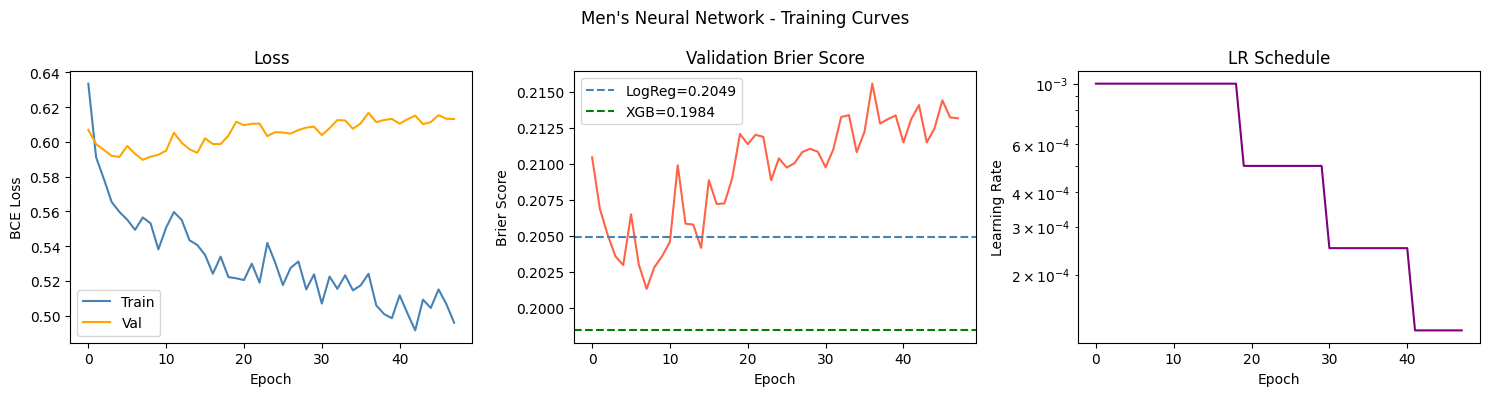

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Men's Neural Network - Training Curves")

# Loss
axes[0].plot(m_nn.history['train_loss'], label='Train', color='steelblue')
axes[0].plot(m_nn.history['val_loss'], label='Val', color='orange')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('BCE Loss')
axes[0].legend()
axes[0].set_title('Loss')

# Brier Score
axes[1].plot(m_nn.history['val_brier'], color='tomato')
axes[1].axhline(m_lr_brier, linestyle='--', color='steelblue', label=f'LogReg={m_lr_brier:.4f}')
if m_xgb_brier:
    axes[1].axhline(m_xgb_brier, linestyle='--', color='green', label=f'XGB={m_xgb_brier:.4f}')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Brier Score')
axes[1].legend()
axes[1].set_title('Validation Brier Score')

# Learning Rate
axes[2].plot(m_nn.history['lr'], color='purple')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Learning Rate')
axes[2].set_title('LR Schedule')
axes[2].set_yscale('log')

plt.tight_layout()
# plt.savefig(OUT_DIR / 'training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Model Comparison

In [36]:
print("\n" + "="*60)
print("MEN'S MODEL COMPARISON (Holdout 2023-2025)")
print("="*60)
evaluate(m_y_val, naive_05, 'Naive 0.5')
evaluate(m_y_val, naive_seed, 'Seed Heuristic')
evaluate(m_y_val, m_lr_preds, 'Logistic Regression')
if m_xgb_preds is not None:
    evaluate(m_y_val, m_xgb_preds, 'XGBoost')
evaluate(m_y_val, m_nn_preds, 'Neural Network (Standard)')
evaluate(m_y_val, m_nn_res_preds, 'Neural Network (Residual)')
evaluate(m_y_val, m_nn_cal_preds, 'NN + Temperature Scaling')


MEN'S MODEL COMPARISON (Holdout 2023-2025)
Naive 0.5                                 Brier=0.2500  LogLoss=0.6931
Seed Heuristic                            Brier=0.1953  LogLoss=0.5727
Logistic Regression                       Brier=0.2049  LogLoss=0.5998
XGBoost                                   Brier=0.1984  LogLoss=0.5977
Neural Network (Standard)                 Brier=0.2013  LogLoss=0.5897
Neural Network (Residual)                 Brier=0.1980  LogLoss=0.5819
NN + Temperature Scaling                  Brier=0.2273  LogLoss=0.6458


(0.22728622830467113, 0.6458122352141944)

## 10. Ensemble

In [37]:
# Create ensemble with best models
models_for_ensemble = [m_logreg, best_nn]
weights = [0.3, 0.7]  # Give more weight to NN

if m_xgb is not None:
    models_for_ensemble = [m_logreg, m_xgb, best_nn]
    weights = [0.2, 0.3, 0.5]

m_ensemble = EnsemblePredictor(models_for_ensemble, weights)
m_ens_preds = m_ensemble.predict_proba(m_X_val)

print("\n=== Ensemble ===")
m_ens_brier, m_ens_ll = evaluate(m_y_val, m_ens_preds, 'Ensemble (val)')
m_ens_ece = compute_expected_calibration_error(m_y_val, m_ens_preds)
print(f"Ensemble ECE: {m_ens_ece:.4f}")


=== Ensemble ===
Ensemble (val)                            Brier=0.1948  LogLoss=0.5757
Ensemble ECE: 0.1180


## 11. Calibration Plot

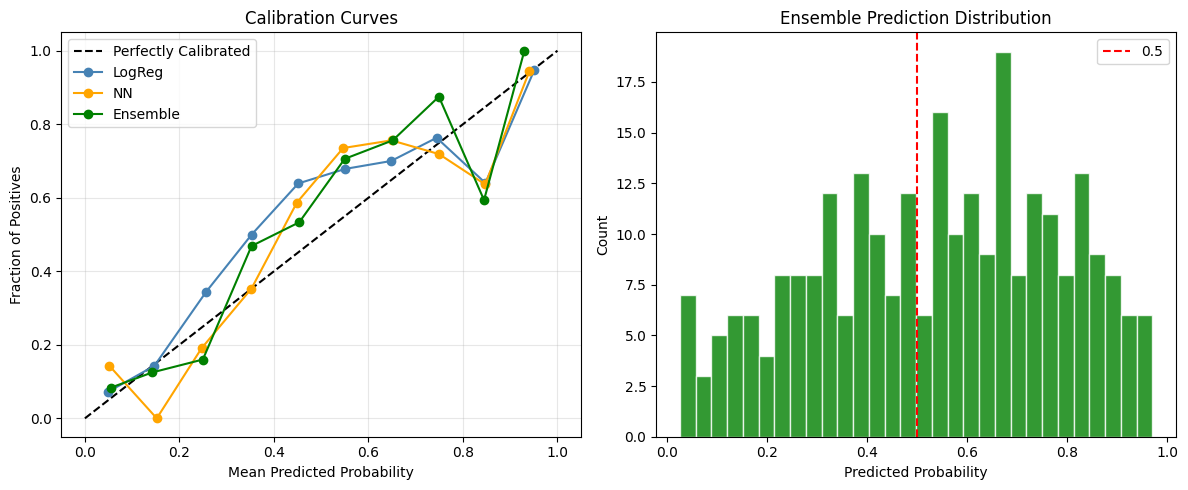

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Calibration curves
ax = axes[0]
ax.plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated')

for preds, name, color in [
    (m_lr_preds, 'LogReg', 'steelblue'),
    (m_nn_preds, 'NN', 'orange'),
    (m_ens_preds, 'Ensemble', 'green'),
]:
    frac_pos, mean_pred = compute_calibration(m_y_val, preds, n_bins=10)
    ax.plot(mean_pred, frac_pos, 'o-', label=name, color=color)

ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('Calibration Curves')
ax.legend()
ax.grid(True, alpha=0.3)

# Prediction distribution
ax = axes[1]
ax.hist(m_ens_preds, bins=30, color='green', edgecolor='white', alpha=0.8)
ax.axvline(0.5, color='red', linestyle='--', label='0.5')
ax.set_xlabel('Predicted Probability')
ax.set_ylabel('Count')
ax.set_title('Ensemble Prediction Distribution')
ax.legend()

plt.tight_layout()
#plt.savefig(OUT_DIR / 'calibration.png', dpi=120, bbox_inches='tight')
plt.show()

## 12. Women's Models

In [39]:
print("=== Women's Logistic Regression ===")
w_logreg = LogisticBaseline(C=0.1)
w_logreg.fit(w_X_train, w_y_train, feature_names=w_feature_cols)
w_lr_preds = w_logreg.predict_proba(w_X_val)
w_lr_brier, _ = evaluate(w_y_val, w_lr_preds, 'Women LogReg (val)')

print("\n=== Women's Neural Network ===")
w_nn = MarchMadnessTrainer(
    hidden_dims=[64, 32],
    dropout = 0.5,
    activation='relu',
    use_residual=True,
    lr=.001,
    weight_decay=.001,
    batch_size=32,
    max_epochs=300,
    patience=50,
    label_smoothing=0.02,
    lr_scheduler='plateau'
)

w_nn.fit(w_X_train, w_y_train, w_X_val, w_y_val, feature_names=w_feature_cols)

w_nn_preds = w_nn.predict_proba(w_X_val)
w_nn_brier, _ = evaluate(w_y_val, w_nn_preds, 'Women NN (val)')

print("\n--- Women's Model Comparison ---")
w_naive = np.full(len(w_y_val), 0.5)
evaluate(w_y_val, w_naive, 'Naive 0.5')
evaluate(w_y_val, w_lr_preds, 'Logistic Regression')
evaluate(w_y_val, w_nn_preds, 'Neural Network')

=== Women's Logistic Regression ===
Women LogReg (val)                        Brier=0.1518  LogLoss=0.4537

=== Women's Neural Network ===
Using Apple MPS (GPU)

Input dimension: 45
Architecture: [64, 32]
Residual: True, Activation: relu

Starting training (max 300 epochs, patience=50)...
----------------------------------------------------------------------
Epoch   1 | train=0.6002 val=0.5472 brier=0.1832 lr=1.00e-03 (*best*)
Epoch  10 | train=0.4542 val=0.4714 brier=0.1582 lr=1.00e-03 (wait 1)
Epoch  20 | train=0.4368 val=0.4548 brier=0.1518 lr=1.00e-03 (*best*)
Epoch  30 | train=0.4058 val=0.4606 brier=0.1543 lr=1.00e-03 (wait 6)
Epoch  40 | train=0.3960 val=0.4651 brier=0.1559 lr=5.00e-04 (wait 16)
Epoch  50 | train=0.3971 val=0.4605 brier=0.1545 lr=2.50e-04 (wait 26)
Epoch  60 | train=0.3914 val=0.4674 brier=0.1569 lr=1.25e-04 (wait 36)
Epoch  70 | train=0.3860 val=0.4660 brier=0.1566 lr=6.25e-05 (wait 46)

Early stopping at epoch 74. Best Brier: 0.1513

Training complete. Best va

(0.1512794562396499, 0.45547462348447404)

## 13. Save Models and Results

In [40]:
# Save all models
m_logreg.save(tag='M')
best_nn.save(tag='M')
if m_xgb:
    m_xgb.save(tag='M')

w_logreg.save(tag='W')
w_nn.save(tag='W')

print("\nAll models saved to models/ directory")

Preprocessor saved to /Users/adamgold/Desktop/MM_26/models/M_logreg_prep.pkl
Preprocessor saved to /Users/adamgold/Desktop/MM_26/models/M_nn_prep.pkl
Model saved -> models/M_nn.pt
Preprocessor saved to /Users/adamgold/Desktop/MM_26/models/M_xgb_prep.pkl
Preprocessor saved to /Users/adamgold/Desktop/MM_26/models/W_logreg_prep.pkl
Preprocessor saved to /Users/adamgold/Desktop/MM_26/models/W_nn_prep.pkl
Model saved -> models/W_nn.pt

All models saved to models/ directory


In [41]:
# Determine best model for each gender
m_best_model = 'ensemble'
m_best_brier = m_ens_brier

w_best_model = 'logreg' if w_lr_brier < w_nn_brier else 'nn'
w_best_brier = min(w_lr_brier, w_nn_brier)

results = {
    "M": {
        "best_model": m_best_model,
        "logreg_brier": round(m_lr_brier, 5),
        "xgb_brier": round(m_xgb_brier, 5) if m_xgb_brier else None,
        "nn_brier": round(m_nn_brier, 5),
        "ensemble_brier": round(m_ens_brier, 5),
        "ensemble_weights": weights,
        "feature_cols": m_feature_cols,
    },
    "W": {
        "best_model": w_best_model,
        "logreg_brier": round(w_lr_brier, 5),
        "nn_brier": round(w_nn_brier, 5),
        "feature_cols": w_feature_cols,
    }
}

with open(PROC_DIR / 'model_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("\nModel results saved to data/processed/model_results.json")
print(json.dumps(results, indent=2))


Model results saved to data/processed/model_results.json
{
  "M": {
    "best_model": "ensemble",
    "logreg_brier": 0.20491,
    "xgb_brier": 0.19843,
    "nn_brier": 0.20131,
    "ensemble_brier": 0.19484,
    "ensemble_weights": [
      0.2,
      0.3,
      0.5
    ],
    "feature_cols": [
      "diff_PointsFor",
      "diff_PointsAgn",
      "diff_WinPct",
      "diff_ASTpg",
      "diff_TOpg",
      "diff_STLpg",
      "diff_BLKpg",
      "diff_ORpg",
      "diff_DRpg",
      "diff_PFpg",
      "diff_PointDiff",
      "diff_FGpct",
      "diff_FG3pct",
      "diff_FTpct",
      "diff_FG3Rate",
      "diff_eFG_pct",
      "diff_TOV_pct",
      "diff_ORB_pct",
      "diff_FTR",
      "diff_Opp_eFG_pct",
      "diff_Opp_TOV_pct",
      "diff_DRB_pct",
      "diff_Opp_FTR",
      "diff_Tempo",
      "diff_OffEff",
      "diff_DefEff",
      "diff_NetEff",
      "diff_Recent_WinPct",
      "diff_Recent_PointDiff",
      "diff_Recent_Games",
      "diff_Recent_Tempo",
      "diff_Rec

## 14. (Optional) Hyperparameter Grid Search

Uncomment and run this section to perform a manual grid search.

In [42]:
# Best parameters: {'hidden_dims': [64, 32], 'dropout': 0.5, 'lr': 0.0005, 'weight_decay': 0.001, 'use_residual': True, 'activation': 'relu'}
# Best Brier: 0.1819


# # Define parameter grid
# param_grid = {
#     # Smaller architectures only — your best model was already simple
#     # 256-128-64 was clearly too large given the overfitting
#     "hidden_dims": [[32, 16], [64, 32], [64, 32, 16]],

#     # Higher dropout range — 0.2 was too low, push toward more regularization
#     "dropout": [0.3, 0.4, 0.5],

#     # Lower LR range — 1e-3 caused the spiking val loss with cosine scheduler
#     "lr": [1e-4, 3e-4, 5e-4],

#     # Keep both but weight_decay deserves searching too — L2 is critical here
#     "weight_decay": [1e-3, 5e-3, 1e-2],

#     # Residual blocks are overkill at these small dims, but keep for comparison
#     "use_residual": [False, True],

#     # relu vs gelu matters less than architecture — keep but don't expand
#     "activation": ["relu", "gelu"],
# }

# # Run grid search
# best_params, best_brier, best_model = manual_grid_search(
#     m_X_train, m_y_train, m_X_val, m_y_val,
#     param_grid,
#     feature_names=m_feature_cols
# )

# print(f"\nBest parameters: {best_params}")
# print(f"Best Brier: {best_brier:.4f}")

## Summary

| Model | Val Brier (Men) | Val Brier (Women) |
|-------|-----------------|-------------------|
| Naive 0.5 | 0.2500 | 0.2500 |
| Logistic Regression | | |
| XGBoost | | N/A |
| Neural Network | | |
| **Ensemble** | | |

**Next:** `04_predict.ipynb` - generate final predictions and submission file